In [1]:
#Import modules
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
import numpy as np
import pandas as pd
import geopandas as gpd
import rasterio
import os
import folium
from folium.plugins import TimeSliderChoropleth

#Google Drive Folder Created
drive_directory = '/home/jovyan/data/Tutorial_data/scratch/GEE_test/roblar/S2/'
#List of file names with file path
drive_files = os.listdir(drive_directory)
print(drive_files)

#Dictionary where .tif file paths 
files_by_quarter = {}

#Loops through drive directory
for drive_files in os.listdir(drive_directory):
    try:
        #Finds the directories for each .tif file
        directories = [drive_directory+drive_files+'/SAT/'+tifs for tifs in os.listdir(drive_directory+drive_files+'/SAT')]
    
        #Appends the directories for each .tif file to a dictonary with the date as the key
        files_by_quarter[drive_files]=directories
        
    except FileNotFoundError:
        #If there are no .tif files for the drive_ directory, error message printed and continues to the next directory
        print(f"No .tif in Directory {drive_directory+drive_files+'/SAT'}. Skipping the directory.")
        continue

['2024-07-01', '2023-01-01', '2020-07-01', '2016-04-01', '2024-01-01', '2019-07-01', '2017-04-01', '2016-10-01', '2020-04-01', '2023-07-01', '2019-04-01', '2017-01-01', '2022-10-01', '2021-04-01', '2022-04-01', '2023-10-01', '2022-01-01', '2024-04-01', '2021-10-01', '2020-10-01', '2017-10-01', '2018-07-01', '2022-07-01', '2018-10-01', '2018-04-01', '2016-01-01', '2017-07-01', '2016-07-01', '2019-01-01', '2023-04-01', '2019-10-01', '2021-01-01', '2024-10-01', '2020-01-01', '2018-01-01', '2021-07-01']
No .tif in Directory /home/jovyan/data/Tutorial_data/scratch/GEE_test/roblar/S2/2016-04-01/SAT. Skipping the directory.
No .tif in Directory /home/jovyan/data/Tutorial_data/scratch/GEE_test/roblar/S2/2017-04-01/SAT. Skipping the directory.
No .tif in Directory /home/jovyan/data/Tutorial_data/scratch/GEE_test/roblar/S2/2016-10-01/SAT. Skipping the directory.
No .tif in Directory /home/jovyan/data/Tutorial_data/scratch/GEE_test/roblar/S2/2017-01-01/SAT. Skipping the directory.
No .tif in Dire

In [2]:
#Empty dictionary
all_damdata = {}

#Extract data from each file
for quarter, tifs in files_by_quarter.items():
    #Empty list
    data_quarter = []
    for tif in tifs:
    
        #Open the file with rasterio
        with rasterio.open(tif) as dataset:
            #Read the bands (Blue, Green, Red, Near-Infrared)
            #Read as float64 in order to apply the Nan Mask in next step
            blue_band = dataset.read(1).astype(np.float64)  # Blue band (Band 1)
            green_band = dataset.read(2).astype(np.float64) # Green band (Band 2)
            red_band = dataset.read(3).astype(np.float64)   # Red band (Band 3)
            nir_band = dataset.read(4).astype(np.float64)   # Near-Infrared band (Band 4)

            #Since some files do not cover the full region, apply a mask so they are ignored in median calculation
            mask = (blue_band == 0) & (green_band == 0) & (red_band == 0) & (nir_band == 0)
            blue_band[mask] = np.nan
            green_band[mask] = np.nan
            red_band[mask] = np.nan
            nir_band[mask] = np.nan
        
            #Stack the bands as a 4D array
            file_data = np.stack([blue_band, green_band, red_band, nir_band], axis=-1)
        
            #Append file data to the data_quarter list
            data_quarter.append(file_data)

    #Convert to numpy array
    data_quarter = np.array(data_quarter)

    #Median across all files per pixel ignoring masked values
    median_data = np.nanmedian(data_quarter, axis=0)

    #Using first file obtain the geospatial coordinates (Longitude and Latitude)
    with rasterio.open(tifs[0]) as sing_dataset:
        transform = sing_dataset.transform
        rows, cols = median_data.shape[:2]
    
        #Convert row and column indices to spatial coordinates (Longitude and Latitude)
        lon, lat = np.meshgrid(np.arange(cols), np.arange(rows))
        lon, lat = rasterio.transform.xy(transform, lon, lat)

    #Flatten the arrays so they are 1D
    lon = lon.flatten()
    lat = lat.flatten()
    blue = median_data[:, :, 0].flatten()
    green = median_data[:, :, 1].flatten()
    red = median_data[:, :, 2].flatten()
    nir = median_data[:, :, 3].flatten()

    #Create dataframe containing pixel values and coordinates
    damdata = pd.DataFrame({
        'Longitude': lon,
        'Latitude': lat,
        'Blue': blue,
        'Green': green,
        'Red': red,
        'NIR': nir
    })

    #Converting from digital numbers to reflectance as done by: https://docs.sentinel-hub.com/api/latest/data/sentinel-2-l2a/#harmonize-values
    damdata.iloc[:, 2:6] = damdata.iloc[:, 2:6] / 10000

    all_damdata[quarter]=damdata

/tmp/ipykernel_200/2449937916.py:36: RuntimeWarning: All-NaN slice encountered
  median_data = np.nanmedian(data_quarter, axis=0)


In [3]:
#Sorts the dictionary all_damdata by assending date
ordered_damdata = {date: all_damdata[date] for date in sorted(all_damdata)}
#Displays the data for the first date
ordered_damdata[list(ordered_damdata.keys())[0]]

,Longitude,Latitude,Blue,Green,Red,NIR
0,102.849958,27.300026,0.02990,0.04360,0.04520,0.17380
1,102.849958,27.299936,0.02435,0.04130,0.03030,0.19010
2,102.849958,27.299846,0.02425,0.04215,0.03255,0.18720
3,102.849958,27.299757,0.02425,0.04215,0.03255,0.18720
4,102.849958,27.299667,0.03395,0.04910,0.05440,0.17575
...,...,...,...,...,...,...
2484215,103.050013,27.200313,0.03305,0.05260,0.04385,0.22310
2484216,103.050013,27.200223,0.03305,0.05260,0.04385,0.22310
2484217,103.050013,27.200133,0.03205,0.05000,0.04530,0.23010
2484218,103.050013,27.200044,0.02980,0.05280,0.04380,0.25860


In [4]:
#Add additional indexes to use all go from -1 to 1 with help from digital numbers to reflectance conversion
for date in ordered_damdata:

    #Normalized Difference Vegetation Index (NDVI) from: https://custom-scripts.sentinel-hub.com/custom-scripts/sentinel-2/ndvi/
    #NDVI = (NIR - Red)/(NIR + Red)
    ordered_damdata[date]['NDVI'] = (ordered_damdata[date]['NIR'] - ordered_damdata[date]['Red']) / (ordered_damdata[date]['NIR'] + ordered_damdata[date]['Red'])
    #Normalized Difference Water Index (NDWI) from https://custom-scripts.sentinel-hub.com/custom-scripts/sentinel-2/ndwi/
    #NDWI = (Green - NIR)/(Green + NIR)
    ordered_damdata[date]['NDWI'] = (ordered_damdata[date]['Green'] - ordered_damdata[date]['NIR']) / (ordered_damdata[date]['Green'] + ordered_damdata[date]['NIR'])
    #Normalized Differences Suspended Sediment Index(NDSSI) from: https://iopscience.iop.org/article/10.1088/1755-1315/98/1/012058/pdf#:~:text=The%20equation%20to%20identify%20the,by%20the%20presence%20of%20SM.
    #NDSSI = (Blue - NIR)/(Blue + NIR)
    ordered_damdata[date]['NDSSI'] = (ordered_damdata[date]['Blue'] - ordered_damdata[date]['NIR']) / (ordered_damdata[date]['Blue'] + ordered_damdata[date]['NIR'])
    #Normalized Suspended Material Index (NSMI) from: https://iopscience.iop.org/article/10.1088/1755-1315/98/1/012058/pdf#:~:text=The%20equation%20to%20identify%20the,by%20the%20presence%20of%20SM.
    #NSMI = (Red + Green - Blue)/(Red + Green + Blue)
    ordered_damdata[date]['NSMI'] = (ordered_damdata[date]['Red'] + ordered_damdata[date]['Green'] - ordered_damdata[date]['Blue']) / (ordered_damdata[date]['Red'] + ordered_damdata[date]['Green'] + ordered_damdata[date]['Blue'])

    #Nan values are produced 163 for NSMI and 27 for NDSSI, they are set to zero as likely caused by a division by 0
    ordered_damdata[date].fillna(0, inplace=True)

In [5]:
#Shows the statistics of the data
damdata.describe()

,Longitude,Latitude,Blue,Green,Red,NIR,NDVI,NDWI,NDSSI,NSMI
count,2.484220e+06,2.484220e+06,2.484220e+06,2.484220e+06,2.484220e+06,2.484220e+06,2.484220e+06,2.484220e+06,2.484220e+06,2.484220e+06
mean,1.029500e+02,2.724999e+01,3.783257e-02,6.624137e-02,4.756752e-02,3.305771e-01,6.735056e-01,-5.872048e-01,-7.121810e-01,5.057928e-01
std,5.777679e-02,2.891432e-02,2.588561e-02,2.909741e-02,3.671408e-02,1.158105e-01,3.462294e-01,3.573299e-01,3.568589e-01,5.213160e-02
min,1.028500e+02,2.719995e+01,4.800000e-03,5.300000e-03,2.900000e-03,1.000000e-04,-9.912281e-01,-8.681840e-01,-9.503978e-01,-2.269807e-01
25%,1.029000e+02,2.722493e+01,2.560000e-02,5.050000e-02,2.730000e-02,2.894000e-01,6.858721e-01,-7.484401e-01,-8.668181e-01,4.801061e-01
50%,1.029500e+02,2.724999e+01,3.090000e-02,6.000000e-02,3.650000e-02,3.455000e-01,8.048436e-01,-7.048825e-01,-8.362684e-01,5.147247e-01
75%,1.030000e+02,2.727505e+01,4.020000e-02,7.310000e-02,5.280000e-02,3.961000e-01,8.556327e-01,-6.278586e-01,-7.696589e-01,5.406699e-01
max,1.030500e+02,2.730003e+01,1.073600e+00,1.108000e+00,1.041600e+00,1.150400e+00,9.454971e-01,9.959839e-01,9.932886e-01,7.896951e-01


In [6]:
#Shows there are no Nan values in the data (Done for the first date)
np.sum(np.isnan(ordered_damdata[list(ordered_damdata.keys())[0]]))

/opt/miniconda/envs/ml-env/lib/python3.12/site-packages/numpy/core/fromnumeric.py:86: FutureWarning: The behavior of DataFrame.sum with axis=None is deprecated, in a future version this will reduce over both axes and return a scalar. To retain the old behavior, pass axis=0 (or do not pass axis)
  return reduction(axis=axis, out=out, **passkwargs)


Longitude    0
Latitude     0
Blue         0
Green        0
Red          0
NIR          0
NDVI         0
NDWI         0
NDSSI        0
NSMI         0
dtype: int64

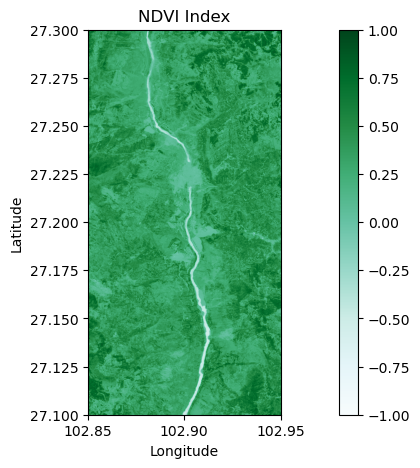

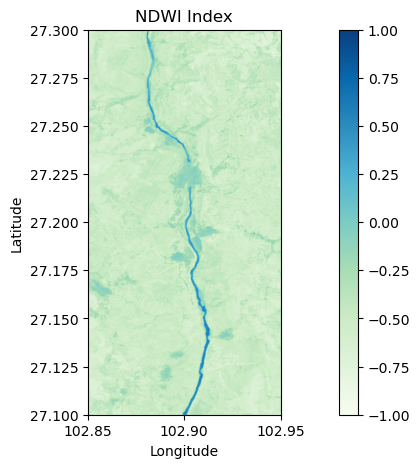

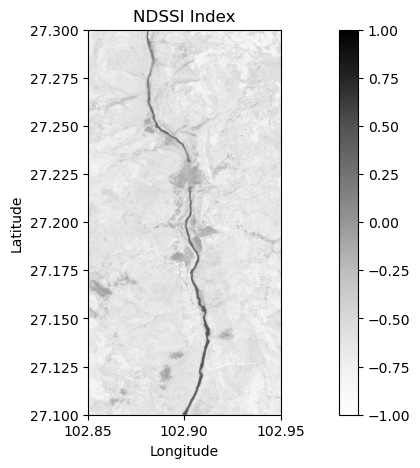

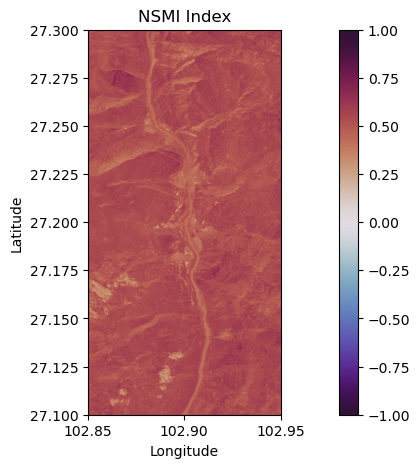

In [7]:
#Visualise the additional indexes

def plot_band(band_data, band_name, colour):
    """
    Plots a given band or index from the DataFrame.
    
    :param band_data: Flattened band or index data (1D array)
    :param band_name: The name of the band or index  (e.g., 'Blue' or 'NDVI')
    :param colour: The name of the cmap to display the data
    """
    
    #Define the extent for the plot
    extent = (102.85, 102.95, 27.10, 27.30)
    
    #Replace all zero values with a small positive number for logarithmic scaling
    band_data[band_data == 0.0] = np.min(band_data[band_data != 0])  #Replaces zero values with lowest non-zero in the data
    
    #Reshape to 2D from 1D
    band_reshaped = band_data.reshape(blue_band.shape)    
    
    #Plot the band or indexes
    plt.figure(figsize=(15, 5))
    plt.imshow(band_reshaped, cmap=colour, extent=extent, vmin=-1, vmax=1)
    plt.colorbar()
    plt.title(f'{band_name} Index')
    plt.xlabel('Longitude')
    plt.ylabel('Latitude')
    plt.show()

#Use the function to plot the desired band or index (Done for the first date)
plot_band(ordered_damdata[list(ordered_damdata.keys())[0]]['NDVI'].values, 'NDVI', 'BuGn')
plot_band(ordered_damdata[list(ordered_damdata.keys())[0]]['NDWI'].values, 'NDWI', 'GnBu')
plot_band(ordered_damdata[list(ordered_damdata.keys())[0]]['NDSSI'].values, 'NDSSI', 'Greys')
plot_band(ordered_damdata[list(ordered_damdata.keys())[0]]['NSMI'].values, 'NSMI', 'twilight_shifted')

2018-01-01


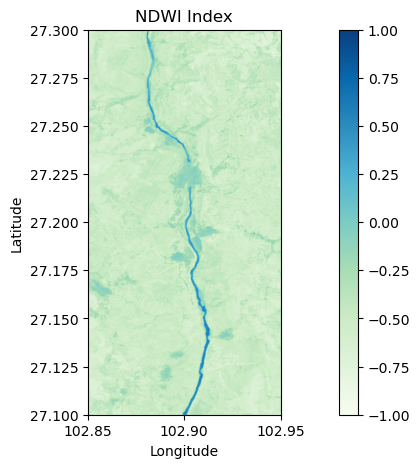

2018-10-01


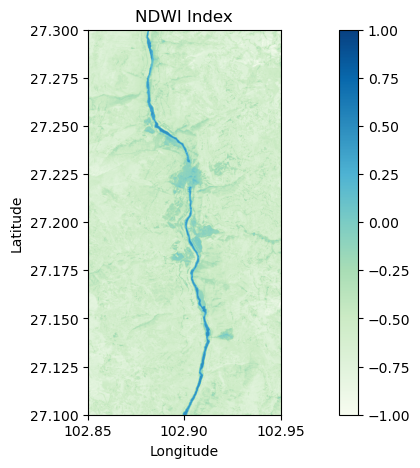

2019-01-01


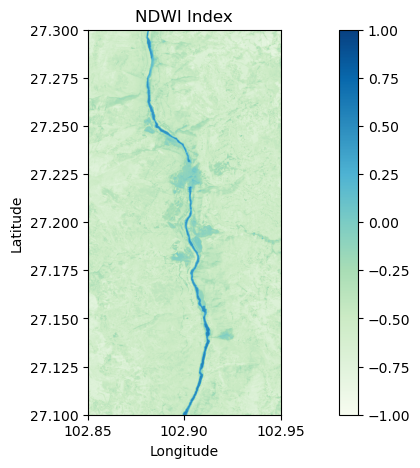

2019-04-01


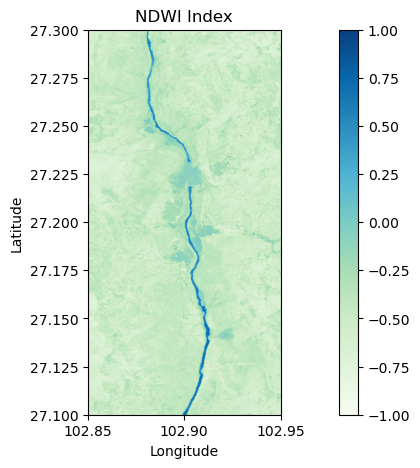

2019-07-01


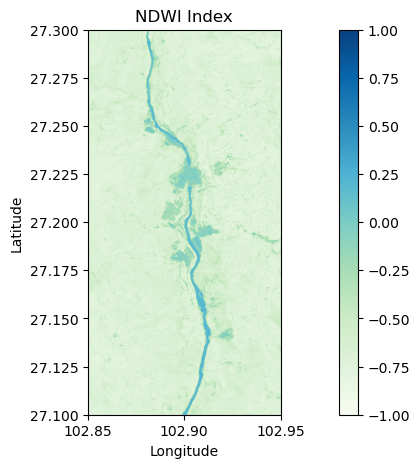

2019-10-01


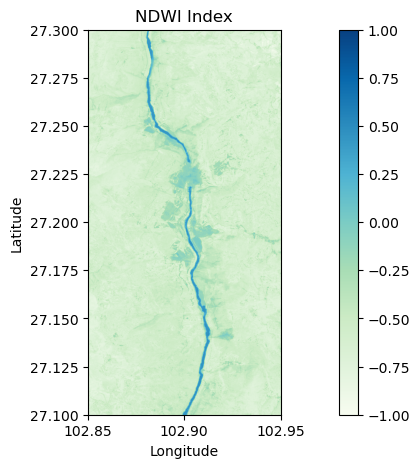

2020-01-01


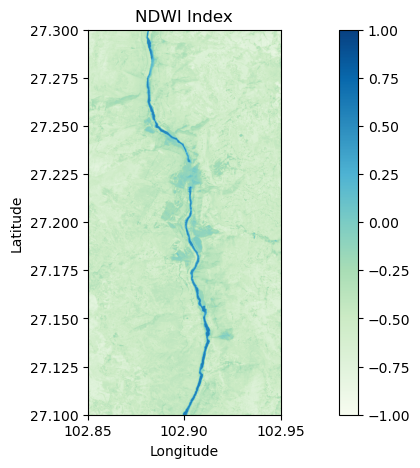

2020-04-01


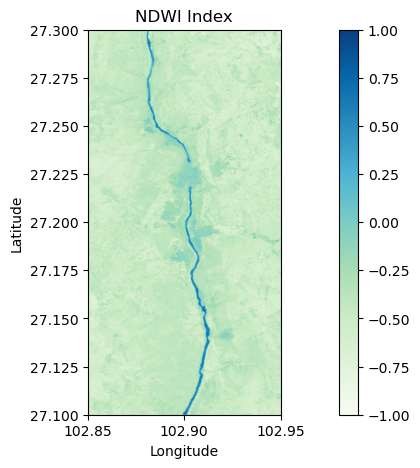

2020-07-01


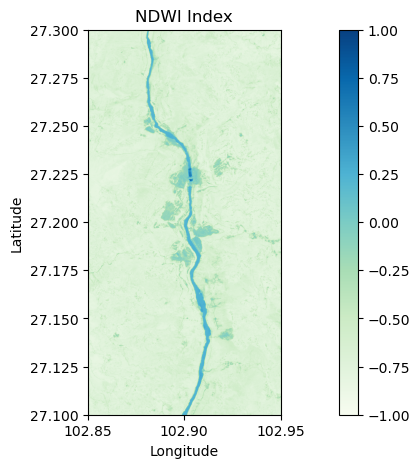

2020-10-01


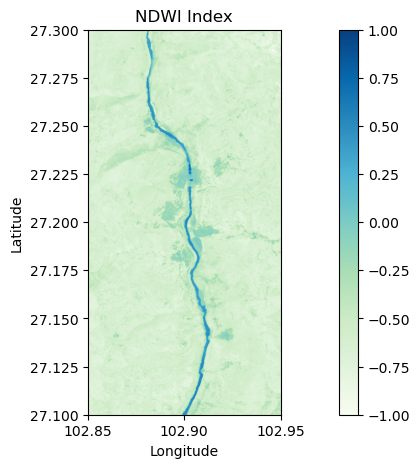

2021-01-01


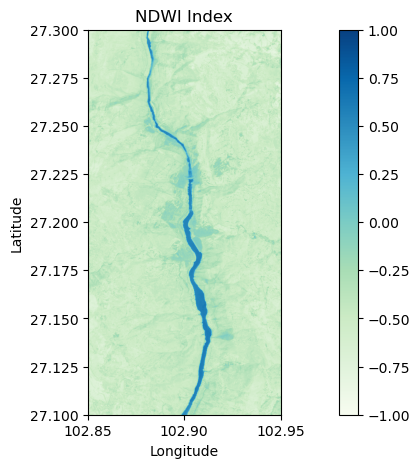

2021-04-01


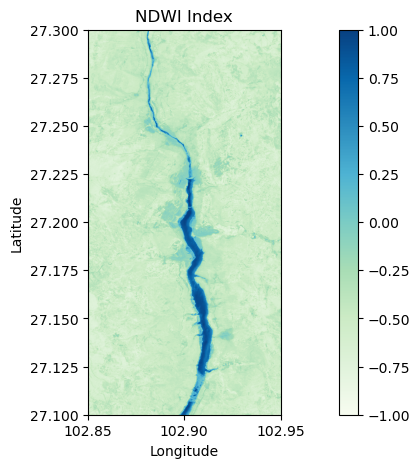

2021-07-01


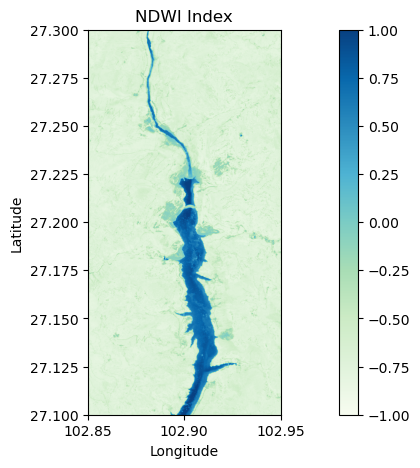

2021-10-01


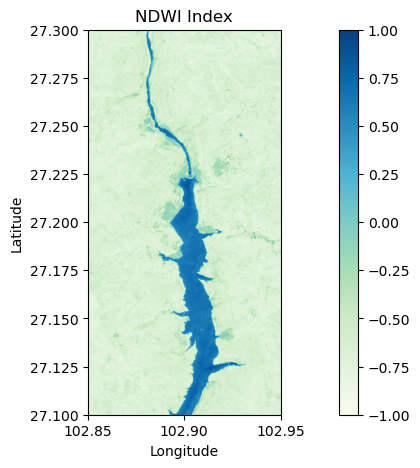

2022-01-01


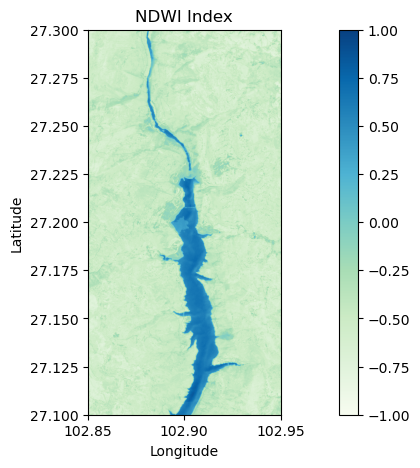

2022-04-01


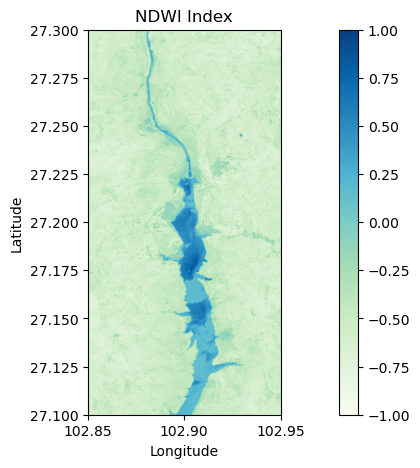

2022-07-01


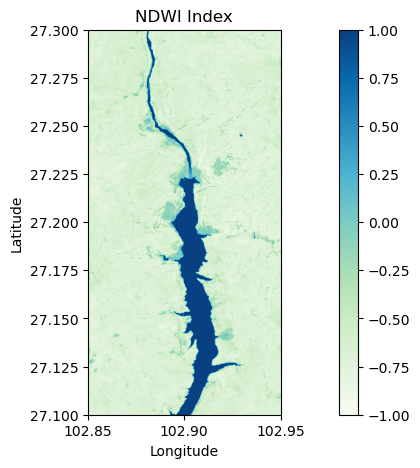

2022-10-01


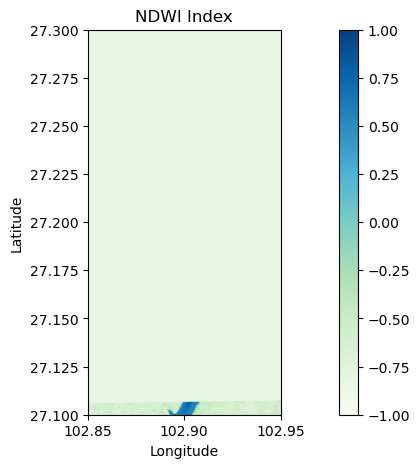

2023-01-01


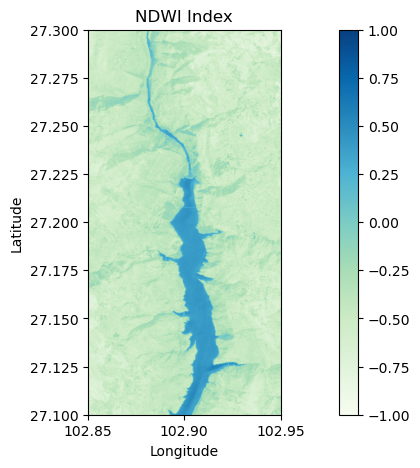

2023-04-01


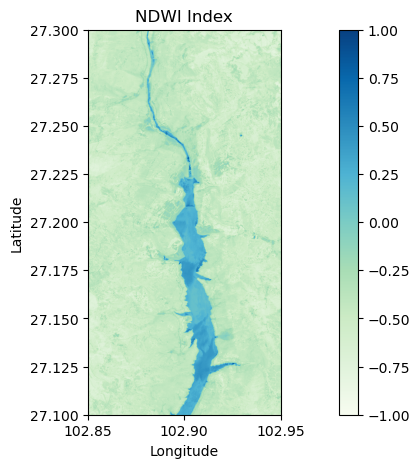

2023-07-01


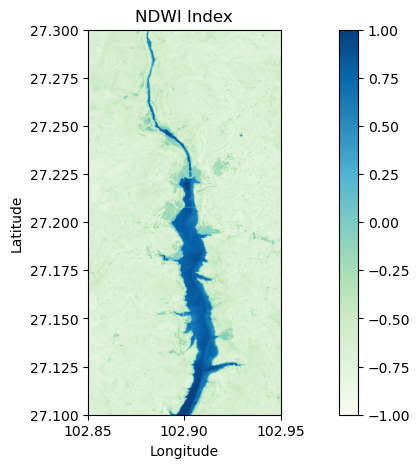

2023-10-01


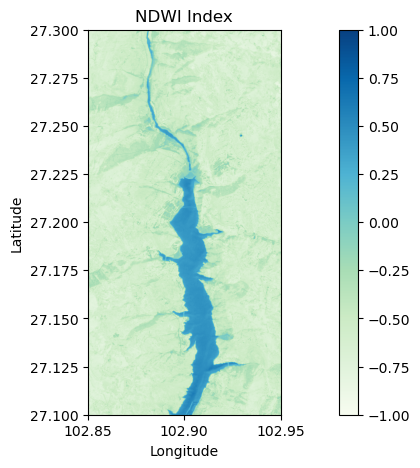

2024-01-01


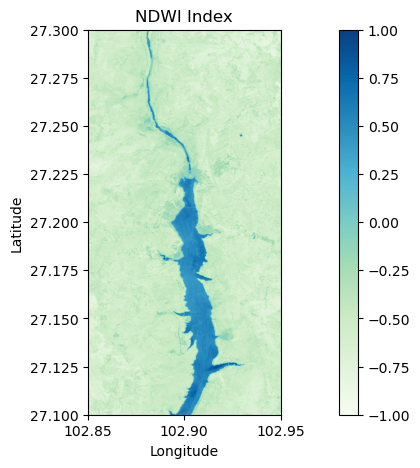

2024-04-01


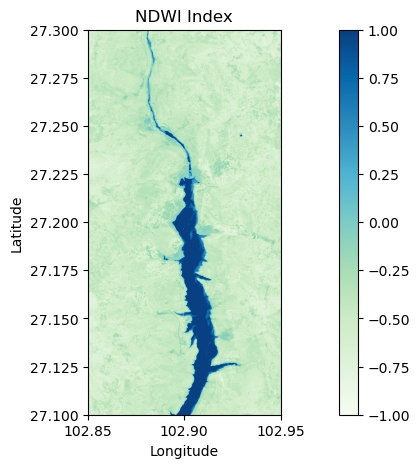

2024-07-01


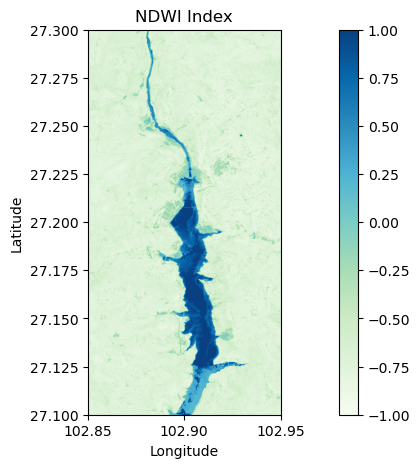

2024-10-01


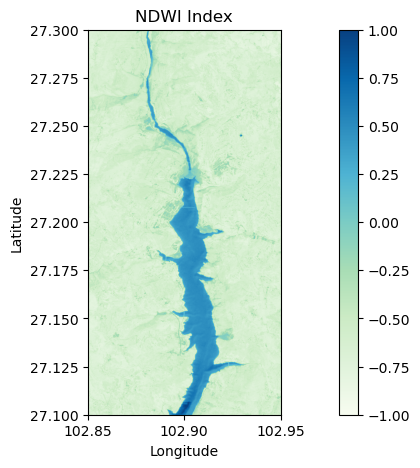

In [8]:
#Plot the NDWI band for every date, will help identify if any quarters had insufficent data
for date in range(0, len(ordered_damdata.keys())):
    print(list(ordered_damdata.keys())[date])
    plot_band(ordered_damdata[list(ordered_damdata.keys())[date]]['NDWI'].values, 'NDWI', 'GnBu')

In [9]:
#Removes the quarter where the data is insufficient
ordered_damdata.pop('2022-10-01')

,Longitude,Latitude,Blue,Green,Red,NIR,NDVI,NDWI,NDSSI,NSMI
0,102.849958,27.300026,0.0000,0.0000,0.0000,0.0000,0.000000,-0.822553,0.000000,0.000000
1,102.849958,27.299936,0.0000,0.0000,0.0000,0.0000,0.000000,-0.822553,0.000000,0.000000
2,102.849958,27.299846,0.0000,0.0000,0.0000,0.0000,0.000000,-0.822553,0.000000,0.000000
3,102.849958,27.299757,0.0000,0.0000,0.0000,0.0000,0.000000,-0.822553,0.000000,0.000000
4,102.849958,27.299667,0.0000,0.0000,0.0000,0.0000,0.000000,-0.822553,0.000000,0.000000
...,...,...,...,...,...,...,...,...,...,...
2484215,103.050013,27.200313,0.0234,0.0264,0.0179,0.0992,0.694278,-0.579618,-0.618271,0.308715
2484216,103.050013,27.200223,0.0234,0.0264,0.0179,0.0992,0.694278,-0.579618,-0.618271,0.308715
2484217,103.050013,27.200133,0.0231,0.0346,0.0159,0.0968,0.717835,-0.473364,-0.614679,0.372283
2484218,103.050013,27.200044,0.0224,0.0406,0.0200,0.1014,0.670511,-0.428169,-0.638126,0.460241
